In [7]:
import numpy as np
from qiskit.circuit.library import ZZFeatureMap
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import (
    FidelityQuantumKernel,
    TrainableFidelityQuantumKernel,
)
from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer
from qiskit_machine_learning.algorithms import QSVC
from qiskit_algorithms.optimizers import SPSA
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

### Quantum kernel learning in quskit

In [8]:
# ---------------------------------------------------
# 1. Create a small binary dataset
# ---------------------------------------------------
X, y = make_moons(n_samples=120, noise=0.15, random_state=42)

# Scale features to a range that works well with angle embeddings
scaler = MinMaxScaler(feature_range=(0, np.pi))
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

n_features = X_train.shape[1]

In [13]:
# ---------------------------------------------------
# 2. Define a trainable quantum feature map
#    Data enters through x params, trainable weights through theta
# ---------------------------------------------------
x = ParameterVector("x", n_features)
theta = ParameterVector("θ", n_features)
feature_map = QuantumCircuit(n_features)

for i in range(n_features):
    feature_map.ry(x[i], i)
    feature_map.rz(theta[i], i)

# Simple entangling layer
for i in range(n_features - 1):
    feature_map.cx(i, i + 1)

# Optional second data re-uploading layer
for i in range(n_features):
    feature_map.ry(x[i], i)

feature_map.draw()

┌──────────┐┌──────────┐     ┌──────────┐
q_0: ┤ Ry(x[0]) ├┤ Rz(θ[0]) ├──■──┤ Ry(x[0]) ├
     ├──────────┤├──────────┤┌─┴─┐├──────────┤
q_1: ┤ Ry(x[1]) ├┤ Rz(θ[1]) ├┤ X ├┤ Ry(x[1]) ├
     └──────────┘└──────────┘└───┘└──────────┘

In [10]:
# ---------------------------------------------------
# 3. Build fidelity object and kernels
# ---------------------------------------------------
sampler = StatevectorSampler()
fidelity = ComputeUncompute(sampler=sampler)

# Fixed kernel baseline: same feature map, but theta fixed later
baseline_kernel = FidelityQuantumKernel(
    feature_map=feature_map.assign_parameters({theta[i]: 0.0 for i in range(n_features)}),
    fidelity=fidelity,
    enforce_psd=True,
)

# Trainable quantum kernel
trainable_kernel = TrainableFidelityQuantumKernel(
    feature_map=feature_map,
    fidelity=fidelity,
    training_parameters=list(theta),
    enforce_psd=True,
)

In [11]:
# ---------------------------------------------------
# 4. Baseline QSVC before kernel training
# ---------------------------------------------------
qsvc_baseline = QSVC(quantum_kernel=baseline_kernel)
qsvc_baseline.fit(X_train, y_train)
y_pred_baseline = qsvc_baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline QSVC accuracy: {baseline_acc:.4f}")

Baseline QSVC accuracy: 0.8333


In [12]:
# ---------------------------------------------------
# 5. Train kernel parameters
# ---------------------------------------------------
optimizer = SPSA(maxiter=40)

trainer = QuantumKernelTrainer(
    quantum_kernel=trainable_kernel,
    loss="svc_loss",
    optimizer=optimizer,
    initial_point=np.zeros(len(theta)),
)

training_result = trainer.fit(X_train, y_train)

optimized_kernel = training_result.quantum_kernel
optimal_point = training_result.optimal_point
optimal_value = training_result.optimal_value

print("Optimal kernel parameters:", optimal_point)
print("Optimal training objective:", optimal_value)

KeyboardInterrupt: 

In [ ]:
# ---------------------------------------------------
# 6. Use trained kernel in QSVC
# ---------------------------------------------------
qsvc_trained = QSVC(quantum_kernel=optimized_kernel)
qsvc_trained.fit(X_train, y_train)
y_pred_trained = qsvc_trained.predict(X_test)
trained_acc = accuracy_score(y_test, y_pred_trained)

print(f"Trained-kernel QSVC accuracy: {trained_acc:.4f}")

In [ ]:
# ---------------------------------------------------
# 7. Inspect train Gram matrix if you want
# ---------------------------------------------------
K_train = optimized_kernel.evaluate(X_train)
print("Train Gram matrix shape:", K_train.shape)
print("Top-left 5x5 block:\n", K_train[:5, :5])

### Gaussian Process Regression with GPJax

In [14]:
# ============================================================
# 1) Classic GPJax regression on a simple 1D dataset
#    Tested against the CURRENT GPJax regression style
# ============================================================

from jax import config
config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx

In [15]:
# -------------------------
# Build a simple 1D dataset
# -------------------------
key = jr.key(123)

n = 40
noise_std = 0.15

x_key, y_key = jr.split(key)
X_train = jr.uniform(x_key, shape=(n, 1), minval=-3.0, maxval=3.0)

def f(x):
    return jnp.sin(1.7 * x) + 0.3 * jnp.cos(4.5 * x)

y_true = f(X_train)
y_train = y_true + noise_std * jr.normal(y_key, shape=y_true.shape)

D = gpx.Dataset(X=X_train, y=y_train)

X_test = jnp.linspace(-3.5, 3.5, 400).reshape(-1, 1)
y_test_true = f(X_test)


In [16]:
# -------------------------
# Define GP prior + likelihood
# -------------------------
kernel = gpx.kernels.RBF()
meanf = gpx.mean_functions.Zero()
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)

likelihood = gpx.likelihoods.Gaussian(num_datapoints=D.n)
posterior = prior * likelihood

In [17]:
# -------------------------
# Fit hyperparameters
# -------------------------
opt_posterior, history = gpx.fit_scipy(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=D,
    trainable=gpx.parameters.Parameter,
)

Optimization terminated successfully.
         Current function value: 9.110244
         Iterations: 10
         Function evaluations: 20
         Gradient evaluations: 20


In [18]:
# -------------------------
# Predict
# -------------------------
latent_dist = opt_posterior.predict(X_test, train_data=D)
predictive_dist = opt_posterior.likelihood(latent_dist)

pred_mean = predictive_dist.mean
pred_std = jnp.sqrt(predictive_dist.variance)

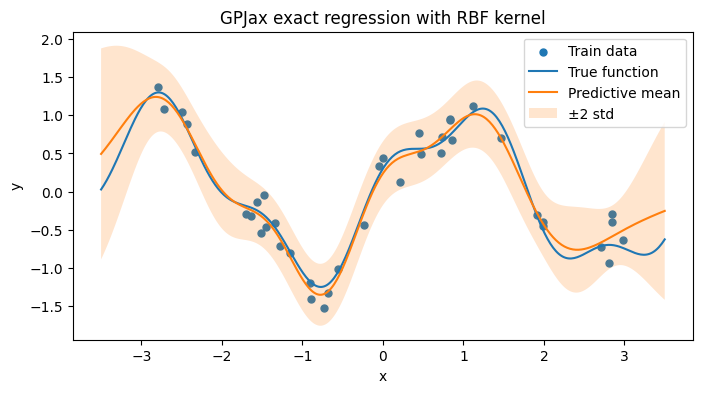

In [19]:
# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 4))
plt.scatter(X_train, y_train, s=25, label="Train data")
plt.plot(X_test, y_test_true, label="True function")
plt.plot(X_test, pred_mean, label="Predictive mean")
plt.fill_between(
    X_test.squeeze(),
    (pred_mean - 2 * pred_std).squeeze(),
    (pred_mean + 2 * pred_std).squeeze(),
    alpha=0.2,
    label="±2 std",
)
plt.legend()
plt.title("GPJax exact regression with RBF kernel")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Quantum kernel for Gaussian Process Regression

Optimized noise variance: 0.10867063706610934


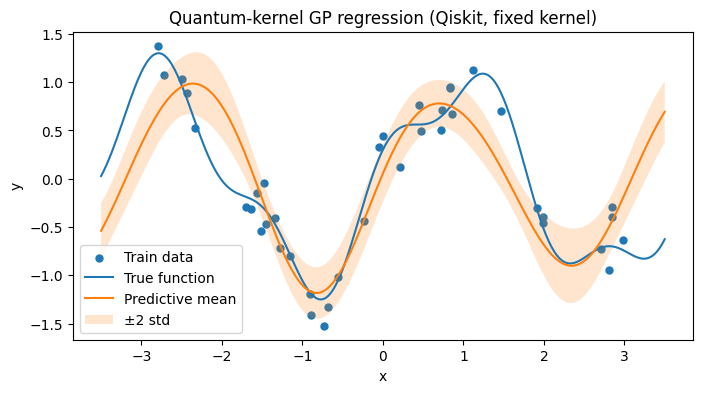

In [24]:
import numpy as np
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.kernels import FidelityStatevectorKernel


# -------------------------------------------------
# 1. Build the same 1D dataset
# -------------------------------------------------
key = jr.key(123)
n = 40
noise_std_true = 0.15

x_key, y_key = jr.split(key)
X_train = jr.uniform(x_key, shape=(n, 1), minval=-3.0, maxval=3.0)

def f(x):
    return jnp.sin(1.7 * x) + 0.3 * jnp.cos(4.5 * x)

y_true = f(X_train)
y_train = y_true + noise_std_true * jr.normal(y_key, shape=y_true.shape)

X_test = jnp.linspace(-3.5, 3.5, 400).reshape(-1, 1)
y_test_true = f(X_test)

X_train_np = np.asarray(X_train, dtype=float)
y_train_np = np.asarray(y_train.squeeze(), dtype=float)
X_test_np = np.asarray(X_test, dtype=float)


# -------------------------------------------------
# 2. Embed 1D -> 2D for a simple 2-qubit feature map
# -------------------------------------------------
def embed_1d_to_2d(X):
    return np.concatenate([X, X], axis=1)


X_train_emb = embed_1d_to_2d(X_train_np)
X_test_emb = embed_1d_to_2d(X_test_np)


# -------------------------------------------------
# 3. Qiskit fixed quantum fidelity kernel
# -------------------------------------------------
x_params = ParameterVector("x", 2)

qc = QuantumCircuit(2)
qc.ry(x_params[0], 0)
qc.ry(x_params[1], 1)
qc.cz(0, 1)
qc.rz(x_params[0], 0)
qc.rz(x_params[1], 1)

qkernel = FidelityStatevectorKernel(
    feature_map=qc,
    enforce_psd=True,
    auto_clear_cache=False,
)


# -------------------------------------------------
# 4. Precompute kernel matrices
# -------------------------------------------------
Kxx = np.asarray(qkernel.evaluate(X_train_emb), dtype=float)
Kxt = np.asarray(qkernel.evaluate(X_train_emb, X_test_emb), dtype=float)
Ktt = np.asarray(qkernel.evaluate(X_test_emb), dtype=float)

# extra stabilization
Kxx = 0.5 * (Kxx + Kxx.T)


# -------------------------------------------------
# 5. Fit only observation noise by marginal likelihood
# -------------------------------------------------
def neg_log_marginal_likelihood(log_noise_var):
    noise_var = np.exp(log_noise_var)
    Ky = Kxx + (noise_var + 1e-6) * np.eye(Kxx.shape[0])

    try:
        L = np.linalg.cholesky(Ky)
    except np.linalg.LinAlgError:
        return np.inf

    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train_np))
    nll = (
        0.5 * y_train_np @ alpha
        + np.sum(np.log(np.diag(L)))
        + 0.5 * len(y_train_np) * np.log(2.0 * np.pi)
    )
    return nll


res = minimize_scalar(
    neg_log_marginal_likelihood,
    bounds=(-8.0, 1.0),
    method="bounded",
)   

log_noise_var_opt = res.x
noise_var_opt = np.exp(log_noise_var_opt)

print("Optimized noise variance:", noise_var_opt)


# -------------------------------------------------
# 6. Predictive mean and covariance
# -------------------------------------------------
Ky = Kxx + (noise_var_opt + 1e-6) * np.eye(Kxx.shape[0])
L = np.linalg.cholesky(Ky)

alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train_np))

# mean: K_*X (K_XX + s^2 I)^-1 y
pred_mean = Kxt.T @ alpha

# variance: K_** - K_*X (K_XX + s^2 I)^-1 K_X*
v = np.linalg.solve(L, Kxt)
pred_cov = Ktt - v.T @ v
pred_var = np.clip(np.diag(pred_cov), 1e-10, None)
pred_std = np.sqrt(pred_var)


# -------------------------------------------------
# 7. Plot
# -------------------------------------------------
plt.figure(figsize=(8, 4))
plt.scatter(X_train_np, y_train_np, s=25, label="Train data")
plt.plot(X_test_np, np.asarray(y_test_true), label="True function")
plt.plot(X_test_np, pred_mean, label="Predictive mean")
plt.fill_between(
    X_test_np.squeeze(),
    pred_mean - 2 * pred_std,
    pred_mean + 2 * pred_std,
    alpha=0.2,
    label="±2 std",
)
plt.legend()
plt.title("Quantum-kernel GP regression (Qiskit, fixed kernel)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()